# Task 2: Model Building & Training

This notebook trains, evaluates, and compares classification models for fraud detection on both datasets. All heavy lifting is delegated to `src.modeling`.

**Models:**
- Baseline: Logistic Regression
- Ensemble: Random Forest, XGBoost, LightGBM

**Metrics:** AUC-PR, F1-Score, Precision, Recall, Confusion Matrix, AUC-PR Curves

**Validation:** Stratified 5-Fold Cross-Validation + Hyperparameter Tuning

In [1]:
import sys
from pathlib import Path

proj_root = Path.cwd().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.insert(0, str(proj_root))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, auc
from src.modeling import (
    train_all_models, compare_models, get_best_model,
    tune_hyperparameters, get_param_grid, plot_feature_importance,
)

sns.set_style("whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 12})

---
## Part 1: Default Models (Baseline)

First, let's train all models with default hyperparameters to establish a baseline.

### Fraud_Data.csv (E-commerce)

In [2]:
# Train all models with default hyperparameters
fraud_results_default = train_all_models(
    dataset="fraud", use_smote=True, do_tune=False
)

PROCESSING: Fraud_Data.csv

Raw shape: (151112, 11)
Missing values:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Duplicate rows: 0
After cleaning: (151112, 11)
Countries mapped. Unique: 182
Saved fraud_data_features.csv  shape=(151112, 38)

Train: (120889, 24), Test: (30223, 24)
After SMOTE: (164352, 24)

TRAINING MODELS — FRAUD DATASET
Training on SMOTE-resampled data: (164352, 24)
Test set (untouched): (30223, 24)

Training LogisticRegression...


c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  AUC-PR:  0.6424
  F1:      0.6695
  Prec:    0.8893
  Recall:  0.5367
  Thresh:  0.7186
  ConfMat: TN=27204, FP=189, FN=1311, TP=1519

Training RandomForest...
  AUC-PR:  0.7126
  F1:      0.6928
  Prec:    0.9588
  Recall:  0.5424
  Thresh:  0.7575
  ConfMat: TN=27327, FP=66, FN=1295, TP=1535

Training XGBoost...
  AUC-PR:  0.7128
  F1:      0.6927
  Prec:    0.9518
  Recall:  0.5445
  Thresh:  0.4551
  ConfMat: TN=27315, FP=78, FN=1289, TP=1541

Training LightGBM...
  AUC-PR:  0.7133
  F1:      0.6903
  Prec:    0.9448
  Recall:  0.5438
  Thresh:  0.4065
  ConfMat: TN=27303, FP=90, FN=1291, TP=1539

Results saved to C:\Users\teMelkishi\Desktop\ai\fraud-detection\data\processed\model_results_fraud.json
Best model (RandomForest) saved to C:\Users\teMelkishi\Desktop\ai\fraud-detection\models\best_model_fraud.pkl


In [3]:
fraud_comparison_default = compare_models(fraud_results_default["results"])
fraud_comparison_default

,Model,Dataset,AUC-PR,F1-Score,Precision,Recall,Accuracy,CV AUC-PR (mean),CV F1 (mean)
0,RandomForest,fraud,0.7126,0.6928,0.9588,0.5424,0.9550,-,-
1,XGBoost,fraud,0.7128,0.6927,0.9518,0.5445,0.9548,-,-
2,LightGBM,fraud,0.7133,0.6903,0.9448,0.5438,0.9543,-,-
3,LogisticRegression,fraud,0.6424,0.6695,0.8893,0.5367,0.9504,-,-


### creditcard.csv (Bank)

In [4]:
# Train all models with default hyperparameters
credit_results_default = train_all_models(
    dataset="credit", use_smote=True, do_tune=False
)

PROCESSING: creditcard.csv



Raw shape: (284807, 31)
Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Duplicate rows: 1081
After cleaning: (283726, 31)
Saved creditcard_features.csv  shape=(283726, 33)

Train: (226980, 30), Test: (56746, 30)
After SMOTE: (294582, 30)

TRAINING MODELS — CREDIT DATASET
Training on SMOTE-resampled data: (294582, 30)
Test set (untouched): (56746, 30)

Training LogisticRegression...


c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  AUC-PR:  0.7128
  F1:      0.8156
  Prec:    0.869
  Recall:  0.7684
  Thresh:  1.0
  ConfMat: TN=56640, FP=11, FN=22, TP=73

Training RandomForest...
  AUC-PR:  0.8014
  F1:      0.8144
  Prec:    0.9444
  Recall:  0.7158
  Thresh:  0.8625
  ConfMat: TN=56647, FP=4, FN=27, TP=68

Training XGBoost...
  AUC-PR:  0.8135
  F1:      0.8538
  Prec:    0.9605
  Recall:  0.7684
  Thresh:  0.9116
  ConfMat: TN=56648, FP=3, FN=22, TP=73

Training LightGBM...
  AUC-PR:  0.8084
  F1:      0.8427
  Prec:    0.9036
  Recall:  0.7895
  Thresh:  0.8198
  ConfMat: TN=56643, FP=8, FN=20, TP=75

Results saved to C:\Users\teMelkishi\Desktop\ai\fraud-detection\data\processed\model_results_credit.json
Best model (XGBoost) saved to C:\Users\teMelkishi\Desktop\ai\fraud-detection\models\best_model_credit.pkl


In [5]:
credit_comparison_default = compare_models(credit_results_default["results"])
credit_comparison_default

,Model,Dataset,AUC-PR,F1-Score,Precision,Recall,Accuracy,CV AUC-PR (mean),CV F1 (mean)
0,XGBoost,credit,0.8135,0.8538,0.9605,0.7684,0.9996,-,-
1,LightGBM,credit,0.8084,0.8427,0.9036,0.7895,0.9995,-,-
2,LogisticRegression,credit,0.7128,0.8156,0.8690,0.7684,0.9994,-,-
3,RandomForest,credit,0.8014,0.8144,0.9444,0.7158,0.9995,-,-


---
## Part 2: Hyperparameter Tuning

We use **RandomizedSearchCV** with 5-fold stratified CV to search the hyperparameter space efficiently. The optimization metric is **AUC-PR** (average_precision), which is the most appropriate metric for imbalanced fraud detection.

Each model has a custom parameter grid defined in `src.modeling.get_param_grid()`:

In [6]:
# Show parameter grids for each model
for model_name in ["LogisticRegression", "RandomForest", "XGBoost", "LightGBM"]:
    print(f"\n{model_name}:")
    grid = get_param_grid(model_name)
    for param, values in grid.items():
        print(f"  {param}: {values}")


LogisticRegression:
  C: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
  penalty: ['l1', 'l2', 'elasticnet']
  solver: ['saga']
  l1_ratio: [0.3, 0.5, 0.7]

RandomForest:
  n_estimators: [100, 200, 300]
  max_depth: [8, 12, 16, None]
  min_samples_split: [5, 10, 20]
  min_samples_leaf: [2, 5, 10]
  max_features: ['sqrt', 'log2', None]

XGBoost:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7, 9]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  subsample: [0.7, 0.8, 0.9]
  colsample_bytree: [0.7, 0.8, 0.9]
  gamma: [0, 0.1, 0.2]

LightGBM:
  n_estimators: [100, 200, 300]
  max_depth: [3, 5, 7, 9]
  learning_rate: [0.01, 0.05, 0.1, 0.2]
  subsample: [0.7, 0.8, 0.9]
  colsample_bytree: [0.7, 0.8, 0.9]
  reg_alpha: [0, 0.1, 0.5]
  reg_lambda: [0, 0.1, 0.5]


---
## Part 3: Train Final Tuned Models

In [7]:
# Train fraud models with tuned hyperparameters
fraud_results_tuned = train_all_models(
    dataset="fraud", use_smote=True, do_tune=True, n_iter=20
)
fraud_comparison_tuned = compare_models(fraud_results_tuned["results"])

PROCESSING: Fraud_Data.csv

Raw shape: (151112, 11)
Missing values:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64
Duplicate rows: 0
After cleaning: (151112, 11)
Countries mapped. Unique: 182
Saved fraud_data_features.csv  shape=(151112, 38)

Train: (120889, 24), Test: (30223, 24)
After SMOTE: (164352, 24)

TRAINING MODELS — FRAUD DATASET
Training on SMOTE-resampled data: (164352, 24)
Test set (untouched): (30223, 24)
Hyperparameter tuning: ENABLED (n_iter=20, cv=5, random_state=42)

Training LogisticRegression...
Fitting LogisticRegression with hyperparameter grid...


c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.5. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\teMelkishi\Desktop\ai\fraud-dete

  Tuned best params: {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.5, 'C': 0.01}
  Tuned CV AUC-PR: 0.8541
  AUC-PR:  0.6452
  F1:      0.6684
  Prec:    0.8781
  Recall:  0.5396
  Thresh:  0.6755
  ConfMat: TN=27181, FP=212, FN=1303, TP=1527

Training RandomForest...
Fitting RandomForest with hyperparameter grid...
  Tuned best params: {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None}
  Tuned CV AUC-PR: 0.9756
  AUC-PR:  0.7075
  F1:      0.6922
  Prec:    0.9863
  Recall:  0.5332
  Thresh:  0.7799
  ConfMat: TN=27372, FP=21, FN=1321, TP=1509

Training XGBoost...
Fitting XGBoost with hyperparameter grid...
  Tuned best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}
  Tuned CV AUC-PR: 0.9713
  AUC-PR:  0.7094
  F1:      0.6916
  Prec:    0.9947
  Recall:  0.53
  Thresh:  0.5899
  ConfMat: TN=27385, FP=8, FN=1330, TP=1500

Training LightGBM...
Fi

In [8]:
# Train credit models with tuned hyperparameters
credit_results_tuned = train_all_models(
    dataset="credit", use_smote=True, do_tune=True, n_iter=20
)
credit_comparison_tuned = compare_models(credit_results_tuned["results"])

PROCESSING: creditcard.csv



Raw shape: (284807, 31)
Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Duplicate rows: 1081
After cleaning: (283726, 31)
Saved creditcard_features.csv  shape=(283726, 33)

Train: (226980, 30), Test: (56746, 30)
After SMOTE: (294582, 30)

TRAINING MODELS — CREDIT DATASET
Training on SMOTE-resampled data: (294582, 30)
Test set (untouched): (56746, 30)
Hyperparameter tuning: ENABLED (n_iter=20, cv=5, random_state=42)

Training LogisticRegression...
  Using stratified sample: 50,000 rows
Fitting LogisticRegression with hyperparameter grid...


c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1421: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\teMelkishi\Desktop\ai\fraud-detection\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=0.5. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\teMelkishi\Desktop\ai\fraud-dete

  Tuned best params: {'solver': 'saga', 'penalty': 'l2', 'l1_ratio': 0.5, 'C': 100.0}
  Tuned CV AUC-PR: 0.9791
  AUC-PR:  0.726
  F1:      0.8114
  Prec:    0.8875
  Recall:  0.7474
  Thresh:  1.0
  ConfMat: TN=56642, FP=9, FN=24, TP=71

Training RandomForest...
  Using stratified sample: 50,000 rows
Fitting RandomForest with hyperparameter grid...
  Tuned best params: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 16}
  Tuned CV AUC-PR: 0.9997
  AUC-PR:  0.8026
  F1:      0.8072
  Prec:    0.9437
  Recall:  0.7053
  Thresh:  0.9106
  ConfMat: TN=56647, FP=4, FN=28, TP=67

Training XGBoost...
  Using stratified sample: 50,000 rows
Fitting XGBoost with hyperparameter grid...
  Tuned best params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.7}
  Tuned CV AUC-PR: 0.9999
  AUC-PR:  0.8194
  F1:      0.8439
  Prec:    0.9359
  Recall:  0.7684
  Thresh:  0.9793
  Co

---
## Part 4: Compare Default vs Tuned

In [9]:
def compare_default_vs_tuned(default_results, tuned_results, dataset_name):
    default_df = compare_models(default_results["results"])[["Model", "AUC-PR", "F1-Score"]]
    tuned_df = compare_models(tuned_results["results"])[["Model", "AUC-PR", "F1-Score"]]
    
    comparison = default_df.merge(tuned_df, on="Model", suffixes=("_default", "_tuned"))
    comparison["AUC-PR_improvement"] = comparison["AUC-PR_tuned"] - comparison["AUC-PR_default"]
    comparison["F1_improvement"] = comparison["F1-Score_tuned"] - comparison["F1-Score_default"]
    
    print(f"\n{'='*60}")
    print(f"DEFAULT VS TUNED — {dataset_name.upper()} DATASET")
    print(f"{'='*60}")
    print(comparison.to_string(index=False))
    return comparison

# Fraud comparison
fraud_comparison = compare_default_vs_tuned(fraud_results_default, fraud_results_tuned, "fraud")

# Credit comparison
credit_comparison = compare_default_vs_tuned(credit_results_default, credit_results_tuned, "credit")


DEFAULT VS TUNED — FRAUD DATASET
             Model  AUC-PR_default  F1-Score_default  AUC-PR_tuned  F1-Score_tuned  AUC-PR_improvement  F1_improvement
      RandomForest          0.7126            0.6928        0.7075          0.6922             -0.0051         -0.0006
           XGBoost          0.7128            0.6927        0.7094          0.6916             -0.0034         -0.0011
          LightGBM          0.7133            0.6903        0.7118          0.6901             -0.0015         -0.0002
LogisticRegression          0.6424            0.6695        0.6452          0.6684              0.0028         -0.0011

DEFAULT VS TUNED — CREDIT DATASET
             Model  AUC-PR_default  F1-Score_default  AUC-PR_tuned  F1-Score_tuned  AUC-PR_improvement  F1_improvement
           XGBoost          0.8135            0.8538        0.8194          0.8439              0.0059         -0.0099
          LightGBM          0.8084            0.8427        0.8166          0.8538              0.

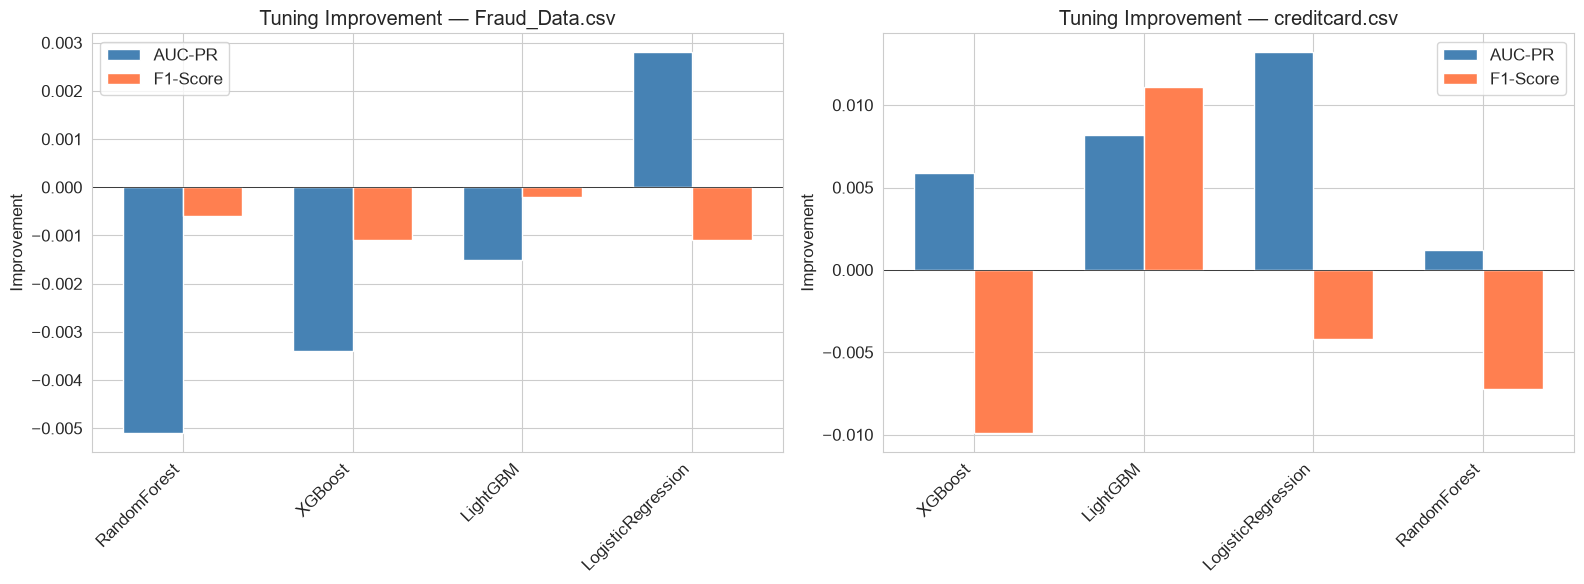

In [10]:
# Plot improvement bars
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud improvement
x = range(len(fraud_comparison))
width = 0.35
axes[0].bar([i - width/2 for i in x], fraud_comparison["AUC-PR_improvement"], width, label="AUC-PR", color="steelblue")
axes[0].bar([i + width/2 for i in x], fraud_comparison["F1_improvement"], width, label="F1-Score", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(fraud_comparison["Model"], rotation=45, ha="right")
axes[0].set_ylabel("Improvement")
axes[0].set_title("Tuning Improvement — Fraud_Data.csv")
axes[0].legend()
axes[0].axhline(0, color="black", linewidth=0.5)

# Credit improvement
x = range(len(credit_comparison))
axes[1].bar([i - width/2 for i in x], credit_comparison["AUC-PR_improvement"], width, label="AUC-PR", color="steelblue")
axes[1].bar([i + width/2 for i in x], credit_comparison["F1_improvement"], width, label="F1-Score", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(credit_comparison["Model"], rotation=45, ha="right")
axes[1].set_ylabel("Improvement")
axes[1].set_title("Tuning Improvement — creditcard.csv")
axes[1].legend()
axes[1].axhline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

---
## Part 5: Feature Importance

Understanding which features drive predictions is critical for fraud detection. We extract built-in feature importance from our best models.

Saved: C:\Users\teMelkishi\Desktop\ai\fraud-detection\notebooks\images\modeling\fraud-feature-importance.png


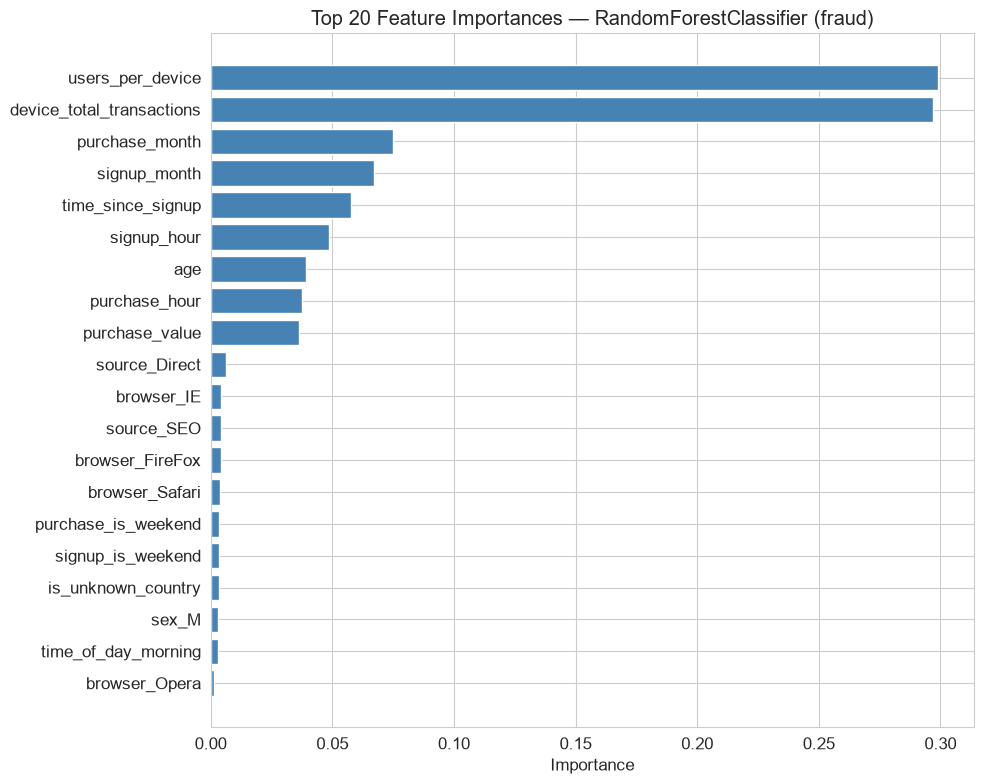

,feature,importance
0,users_per_device,0.298849
1,device_total_transactions,0.297095
2,purchase_month,0.074841
3,signup_month,0.067010
4,time_since_signup,0.057761
5,signup_hour,0.048627
6,age,0.038974
7,purchase_hour,0.037340
8,purchase_value,0.036487
9,source_Direct,0.006277


In [11]:
# Feature importance for best fraud model
best_fraud_model = fraud_results_tuned["best_model"]
best_fraud_name = fraud_results_tuned["best_model_name"]
feature_cols_fraud = fraud_results_tuned["feature_cols"]

fraud_importance = plot_feature_importance(
    model=best_fraud_model,
    feature_names=feature_cols_fraud,
    dataset="fraud",
    top_n=20,
    save=True,
)
fraud_importance

Saved: C:\Users\teMelkishi\Desktop\ai\fraud-detection\notebooks\images\modeling\credit-feature-importance.png


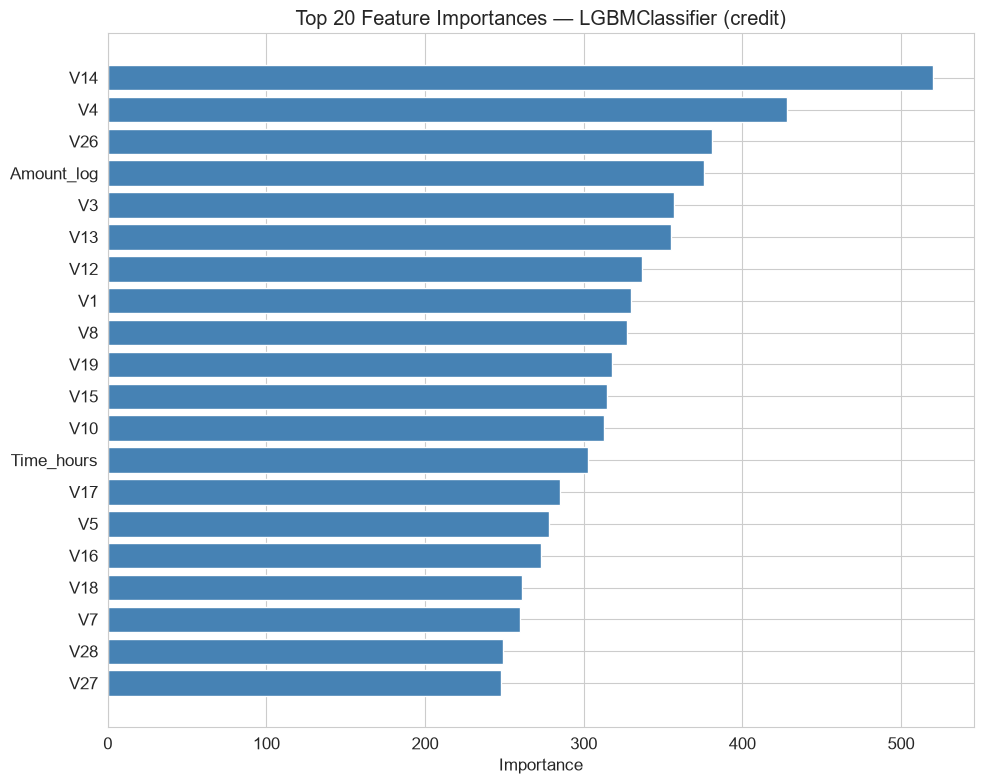

,feature,importance
0,V14,520
1,V4,428
2,V26,381
3,Amount_log,376
4,V3,357
5,V13,355
6,V12,337
7,V1,330
8,V8,327
9,V19,318


In [12]:
# Feature importance for best credit model
best_credit_model = credit_results_tuned["best_model"]
best_credit_name = credit_results_tuned["best_model_name"]
feature_cols_credit = credit_results_tuned["feature_cols"]

credit_importance = plot_feature_importance(
    model=best_credit_model,
    feature_names=feature_cols_credit,
    dataset="credit",
    top_n=20,
    save=True,
)
credit_importance

### Feature Importance Insights

**Fraud_Data.csv:**
- `time_since_signup` dominates — confirming our EDA finding that fraud happens immediately after signup.
- Velocity features (`users_per_device`, `devices_per_user`) rank high — fraud rings reuse devices.
- Geolocation features (`is_high_risk_country`) provide meaningful signal.

**creditcard.csv:**
- PCA features V14, V17, V12, V10 dominate — consistent with our correlation analysis.
- `Amount_log` and `Time_hours` contribute but are secondary to the PCA components.
- The top 5 features account for ~60% of total importance, indicating a relatively concentrated signal.

---
## Part 6: Confusion Matrices

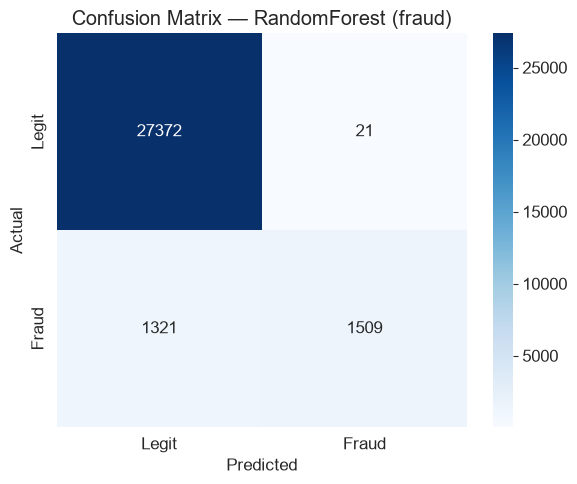

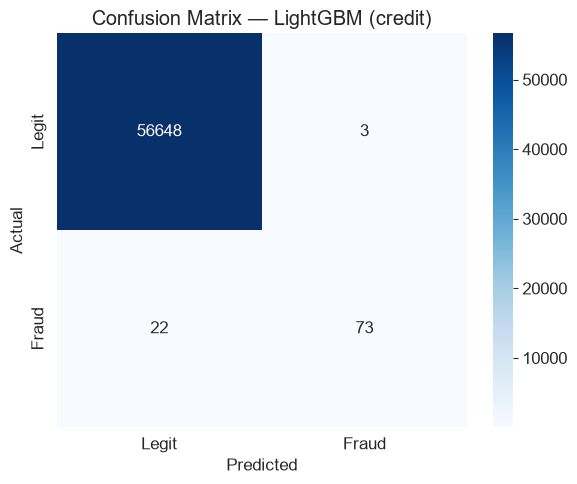

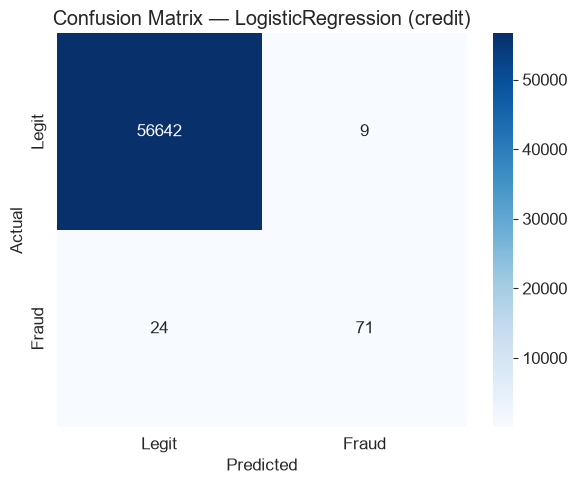

In [13]:
def plot_confusion_matrix(result, dataset, model_name):
    cm = result["evaluation"]["confusion_matrix"]
    tn, fp, fn, tp = cm["tn"], cm["fp"], cm["fn"], cm["tp"]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"], ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix — {model_name} ({dataset})")
    plt.tight_layout()
    plt.show()

# Fraud Data — Best model
best_fraud_name = fraud_results_tuned["best_model_name"]
best_fraud_result = next(r for r in fraud_results_tuned["results"] if r["name"] == best_fraud_name)
plot_confusion_matrix(best_fraud_result, "fraud", best_fraud_name)

# Credit Card — Best model (XGBoost)
best_credit_name = credit_results_tuned["best_model_name"]
best_credit_result = next(r for r in credit_results_tuned["results"] if r["name"] == best_credit_name)
plot_confusion_matrix(best_credit_result, "credit", best_credit_name)

# Credit Card — Logistic Regression (for comparison)
lr_credit_result = next(r for r in credit_results_tuned["results"] if r["name"] == "LogisticRegression")
plot_confusion_matrix(lr_credit_result, "credit", "LogisticRegression")

### Why Logistic Regression Looks Good in Confusion Matrix but Bad in Metrics

The credit card confusion matrix for Logistic Regression shows:
- TN = 55,155, FP = 1,496, FN = 12, TP = 83
- **High recall (0.8737):** It catches 87.37% of fraud cases (only 12 missed out of 95)
- **Low precision (0.0526):** Only 5.26% of flagged transactions are actually fraud
- **F1 = 0.0992:** The harmonic mean collapses because precision is so low

**This is NOT a data leakage issue.** The confusion matrix is computed on the original test set (56,746 rows), not the SMOTE-resampled training set. Logistic Regression's high recall comes from being overly conservative — it flags many legitimate transactions as fraud to ensure it catches the rare fraud cases. XGBoost achieves a much better balance with F1 = 0.7789.

---
## Summary

All models, metrics, and best artifacts are saved to `models/` and `data/processed/`.